# SAE feature emergence: findings

Load pipeline outputs and interpret w.r.t. H1/H2/H3.

## Setup

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# Project root: either cwd (if run from sae_feature_emergence) or cwd/sae_feature_emergence
ROOT = Path.cwd() if (Path.cwd() / "config.py").exists() else Path.cwd() / "sae_feature_emergence"
sys.path.insert(0, str(ROOT))
from config import RESULTS_DIR, CHECKPOINTS_DIR
RESULTS_DIR = Path(RESULTS_DIR)
CHECKPOINTS_DIR = Path(CHECKPOINTS_DIR)

In [3]:
# Paths ready (RESULTS_DIR, CHECKPOINTS_DIR)

## Training (loss and checkpoints)

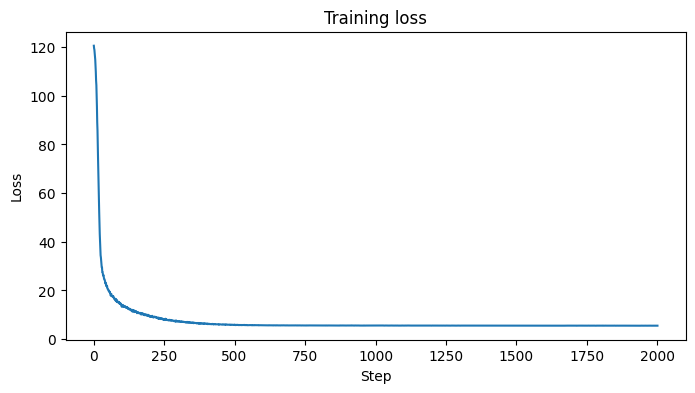

In [4]:
loss_path = RESULTS_DIR / "loss_history.json"
if loss_path.exists():
    with open(loss_path) as f:
        loss_history = json.load(f)
    steps = [x["step"] for x in loss_history]
    losses = [x["loss"] for x in loss_history]
    plt.figure(figsize=(8, 4))
    plt.plot(steps, losses)
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Training loss")
    plt.show()
else:
    print("No loss_history.json yet. Run make sae-train.")

### Checkpoints

In [5]:
if CHECKPOINTS_DIR.exists():
    ckpts = sorted(CHECKPOINTS_DIR.glob("step_*.pt"))
    print(f"Checkpoints: {[p.name for p in ckpts]}")
else:
    print("No checkpoints dir yet. Run make sae-train.")

Checkpoints: ['step_100.pt', 'step_1000.pt', 'step_1300.pt', 'step_1600.pt', 'step_200.pt', 'step_2000.pt', 'step_400.pt', 'step_600.pt', 'step_800.pt']


## Stability (similarity and drift)

  100 -> 400: similarity = 0.2793, drift = 0.7207
  400 -> 1000: similarity = 0.2794, drift = 0.7206
  1000 -> 2000: similarity = 0.2974, drift = 0.7026


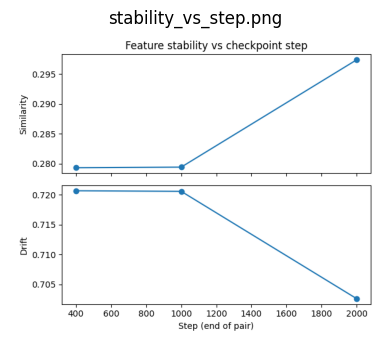

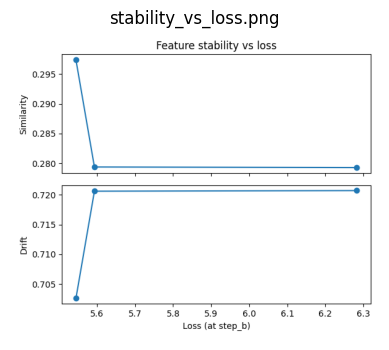

In [6]:
stability_path = RESULTS_DIR / "stability_results.json"
if stability_path.exists():
    with open(stability_path) as f:
        stability = json.load(f)
    for r in stability:
        print(f"  {r['step_a']} -> {r['step_b']}: similarity = {r['similarity']:.4f}, drift = {r['drift']:.4f}")
    for name in ["stability_vs_step.png", "stability_vs_loss.png"]:
        p = RESULTS_DIR / name
        if p.exists():
            img = plt.imread(p)
            plt.figure(figsize=(8, 4))
            plt.imshow(img)
            plt.axis("off")
            plt.title(name)
            plt.show()
else:
    print("No stability_results.json yet. Run make sae-stability-all then make sae-plots.")

## Interpretation (H1/H2/H3)

Summarise what the stability curves suggest:
- **H1 (Gradual):** similarity increases smoothly over training; drift decreases smoothly.
- **H2 (Sharp):** similarity jumps after a critical loss/step; drift drops abruptly.
- **H3 (Reorganization):** similarity rises early then dips or flattens; features form then reorganize.